# Notebook 5 — Bivariate Analysis
### Sprint 4 | Data Inspection & Exploratory Data Analysis (EDA)

**Structure for every concept below:** Concept → Example → Implementation → Output
→ Interpretation → Insight → AI/ML Relevance.

**Dataset:** Telco Customer Churn (7,043 customers, 21 columns), with `TotalCharges`
corrected to numeric (Notebook 3's fix applied).

This notebook directly tests the three hypotheses raised at the end of Notebook 4
(Univariate Analysis):
1. Shorter `tenure` likely correlates with higher churn.
2. `Month-to-month` contracts likely show a much higher churn rate than longer contracts.
3. Manual payment methods (especially Electronic check) likely show higher churn than
   automatic methods.

**Topics:** Numerical vs Numerical · Numerical vs Categorical · Categorical vs
Categorical, using Scatter Plots, Box Plots, Violin Plots, Grouped Bar Charts, and Cross
Tabulation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)

df = pd.read_csv("telco_churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"Dataset ready: {df.shape[0]:,} rows, {df.shape[1]} columns")


Dataset ready: 7,043 rows, 21 columns


---
# Part A — Numerical vs Numerical

Analogous to a classic "Age vs Salary" or "Income vs Spending" bivariate check — here,
examining how `tenure`, `MonthlyCharges`, and `TotalCharges` relate to each other.


---
## A1. `tenure` vs `MonthlyCharges`

### Concept
A scatter plot shows the relationship between two numeric variables directly, point by
point — revealing whether they move together, oppositely, or show no clear pattern
(Sprint 2, Notebook 8).

### Example
**Business example:** Does a customer's monthly bill tend to change (up or down) the
longer they've been with the company? Longer-tenured customers might be on legacy
lower-cost plans, or might have added more premium services over time — this isn't
obvious without checking.

### Implementation


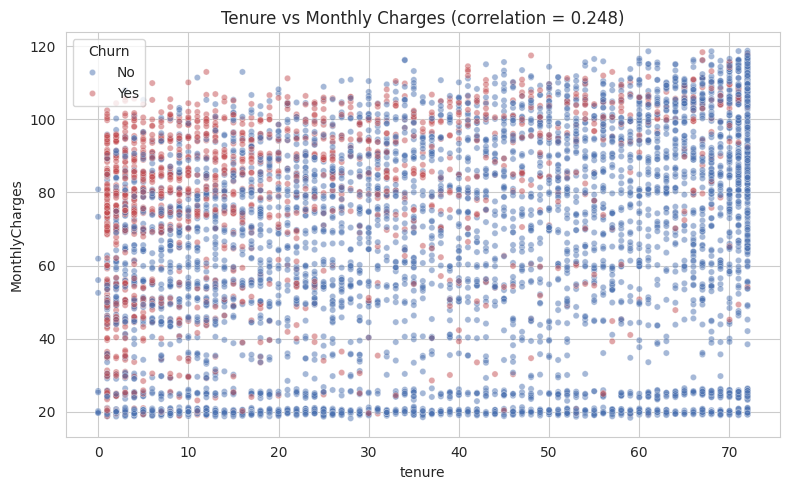

Correlation between tenure and MonthlyCharges: 0.248


In [2]:
correlation = df['tenure'].corr(df['MonthlyCharges'])

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn',
                 palette={'No': '#4C72B0', 'Yes': '#C44E52'}, alpha=0.5, s=20)
plt.title(f'Tenure vs Monthly Charges (correlation = {correlation:.3f})')
plt.tight_layout()
plt.show()

print(f"Correlation between tenure and MonthlyCharges: {correlation:.3f}")


### Output
Correlation ≈ 0.25 — a weak positive relationship. The scatter shows points spread
broadly across the whole plot, with no tight linear band.

### Interpretation
There's only a weak tendency for `MonthlyCharges` to rise with `tenure` — tenure length
does NOT strongly determine what a customer currently pays. This makes business sense:
`MonthlyCharges` mostly reflects which services a customer has chosen, largely
independent of how long they've been a customer.

### Insight
The color-coded churn overlay reveals something more useful than the weak correlation
itself: churned customers (red) are visibly concentrated at **low tenure** across the
*entire* range of monthly charges — churn looks tied to tenure regardless of price point,
not to price itself.

### AI/ML Relevance
A weak correlation here (0.25) means `MonthlyCharges` and `tenure` are NOT strongly
redundant with each other — both are safe to keep as separate features without a serious
multicollinearity concern (Sprint 2, Notebook 12).


---
## A2. `tenure` vs `TotalCharges`

### Concept
Since `TotalCharges` logically accumulates over a customer's tenure, this pair is
expected to show a much stronger relationship than A1 — a good test of whether the data
actually behaves as the business logic would predict.

### Example
**AI/ML use case:** Confirming an expected strong relationship (rather than assuming it)
is good practice — if `TotalCharges` did NOT correlate strongly with `tenure`, that would
itself be a red flag about data quality.

### Implementation


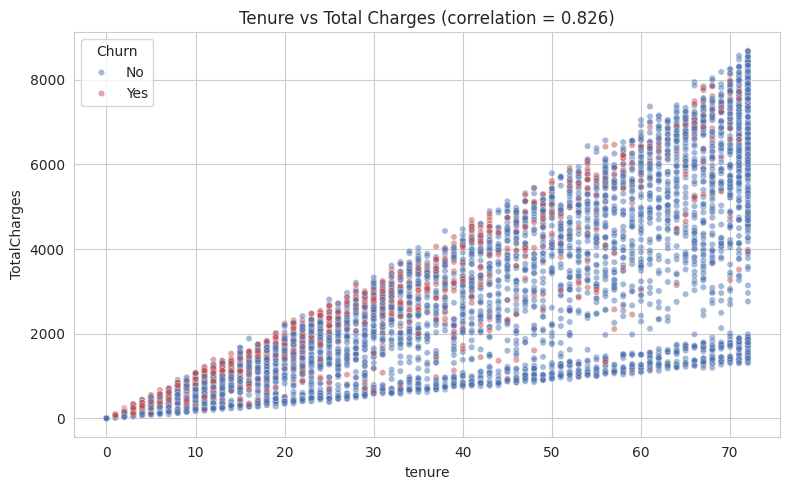

Correlation between tenure and TotalCharges: 0.826


In [3]:
correlation2 = df['tenure'].corr(df['TotalCharges'])

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='tenure', y='TotalCharges', hue='Churn',
                 palette={'No': '#4C72B0', 'Yes': '#C44E52'}, alpha=0.5, s=20)
plt.title(f'Tenure vs Total Charges (correlation = {correlation2:.3f})')
plt.tight_layout()
plt.show()

print(f"Correlation between tenure and TotalCharges: {correlation2:.3f}")


### Output
Correlation ≈ 0.83 — a strong positive relationship, visible as a clear upward band in
the scatter plot (with spread, reflecting different pricing tiers).

### Interpretation
As expected, `TotalCharges` rises strongly with `tenure` — this confirms the data behaves
consistently with real-world business logic (total billing accumulates the longer a
customer stays), which is itself a useful data-quality sanity check, not just an
analytical finding.

### Insight
Churned customers (red) again cluster tightly in the bottom-left — low tenure AND low
total charges — visually reinforcing the same "early-tenure churn risk" pattern seen in
A1, now even more clearly.

### AI/ML Relevance
A correlation this strong (0.83) IS a multicollinearity concern (Sprint 2, Notebook 12) —
`tenure` and `TotalCharges` carry substantially overlapping information, so a future
model (especially a linear one) may benefit from dropping one, or combining them into a
single engineered ratio feature (e.g., average charge per month of tenure).


---
# Part B — Numerical vs Categorical

Analogous to a classic "Department vs Salary" bivariate check — here, examining how
numeric features differ across the categories of `Churn` and `Contract`.


---
## B1. `MonthlyCharges` vs `Churn`

### Concept
A box plot (or violin plot) compares a numeric variable's distribution across different
categories side by side — the direct way to check "does this number tend to differ
between groups?"

### Example
**Business example:** Do customers who churn tend to pay more per month than those who
stay? If price is a major churn driver, this comparison should show a visible difference.

### Implementation


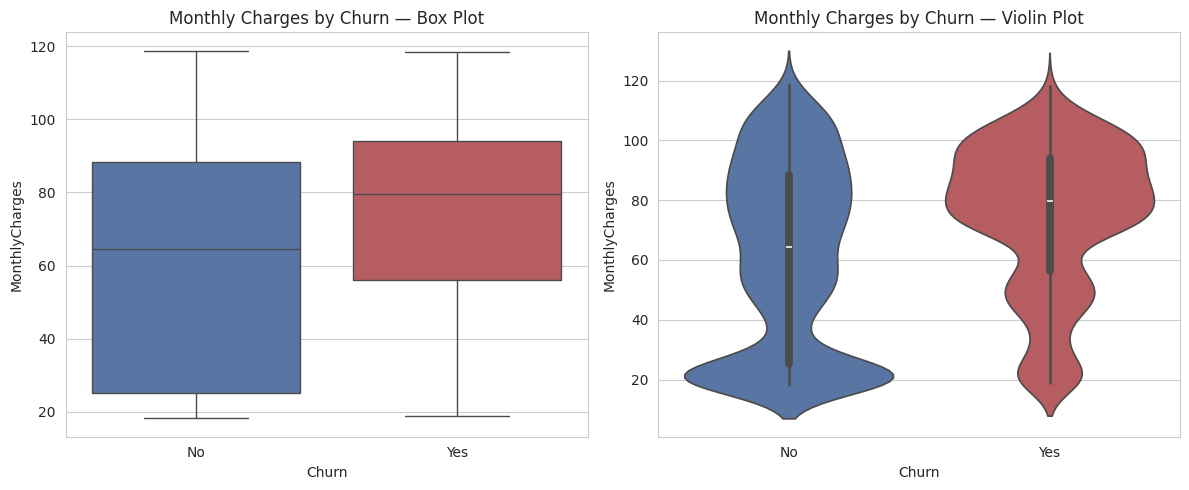

        mean  median
Churn               
No     61.27   64.43
Yes    74.44   79.65


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', order=['No', 'Yes'],
            hue='Churn', palette={'No': '#4C72B0', 'Yes': '#C44E52'}, legend=False, ax=axes[0])
axes[0].set_title('Monthly Charges by Churn — Box Plot')

sns.violinplot(data=df, x='Churn', y='MonthlyCharges', order=['No', 'Yes'],
               hue='Churn', palette={'No': '#4C72B0', 'Yes': '#C44E52'}, legend=False, ax=axes[1])
axes[1].set_title('Monthly Charges by Churn — Violin Plot')

plt.tight_layout()
plt.show()

print(df.groupby('Churn')['MonthlyCharges'].agg(['mean', 'median']).round(2))


### Output
Churned customers: mean \$74.44, median \$79.65. Non-churned customers: mean \$61.27,
median \$64.43 — churned customers pay noticeably more per month.

### Interpretation
The box plot shows the churned group's entire box shifted visibly higher than the
non-churned group's — this isn't a subtle difference. The violin plot adds that the
non-churned group has real weight bunched at the low end (many budget customers who
stay), while the churned group's density leans toward the higher end.

### Insight
This directly contradicts a naive assumption that "low-tenure, low-value customers churn
because they never really committed" — churned customers are actually paying MORE on
average, which suggests price sensitivity or dissatisfaction with a premium plan's value
may be a real churn driver, not just low investment in the relationship.

### AI/ML Relevance
A visible group-level difference like this is a strong signal `MonthlyCharges` will be a
genuinely useful predictive feature — exactly the kind of relationship a model should be
able to learn from, and worth highlighting as a business insight in Notebook 12.


---
## B2. `tenure` vs `Churn`

### Concept
Directly testing Hypothesis 1 from Notebook 4: does `tenure` meaningfully differ between
customers who churned and those who didn't?

### Example
**AI/ML use case:** This is precisely the kind of relationship a churn model needs to
learn — if tenure and churn show no relationship at all here, that would undercut
tenure's usefulness as a predictive feature.

### Implementation


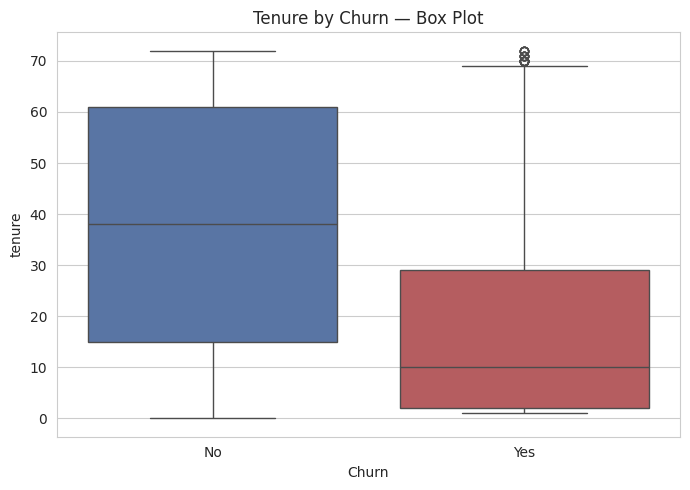

       mean  median
Churn              
No     37.6    38.0
Yes    18.0    10.0


In [5]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Churn', y='tenure', order=['No', 'Yes'],
            hue='Churn', palette={'No': '#4C72B0', 'Yes': '#C44E52'}, legend=False)
plt.title('Tenure by Churn — Box Plot')
plt.tight_layout()
plt.show()

print(df.groupby('Churn')['tenure'].agg(['mean', 'median']).round(1))


### Output
Churned customers: mean tenure 18.0 months, median 10. Non-churned customers: mean
tenure 37.6 months, median 38.

### Interpretation
This is one of the largest, clearest differences in the entire dataset — churned
customers' median tenure (10 months) is roughly a quarter of non-churned customers'
median tenure (38 months). The box plot shows almost no overlap between the two groups'
middle 50%.

### Insight
**Hypothesis 1 is strongly confirmed.** Combined with B1's finding (churners pay more),
a coherent risk profile emerges: newer customers on relatively expensive plans are the
company's highest churn-risk segment — exactly the kind of specific, actionable pattern
this sprint is meant to surface.

### AI/ML Relevance
`tenure` showing this strong a group-level separation makes it very likely to be one of
the top few most important features in an eventual churn model (Sprint 2, Notebook 12's
feature importance) — and a natural candidate for the "early-tenure retention outreach"
business recommendation that will be written up in Notebook 12.


---
## B3. `tenure` vs `Contract`

### Concept
Before testing Contract's relationship with Churn directly (Part C), it's worth checking
whether `Contract` type itself relates to `tenure` — since customers likely only qualify
for longer contracts after some tenure, or self-select into them.

### Example
**Business example:** Are two-year contract customers simply the ones who've naturally
stuck around longest, or does the contract itself change customer behavior?

### Implementation


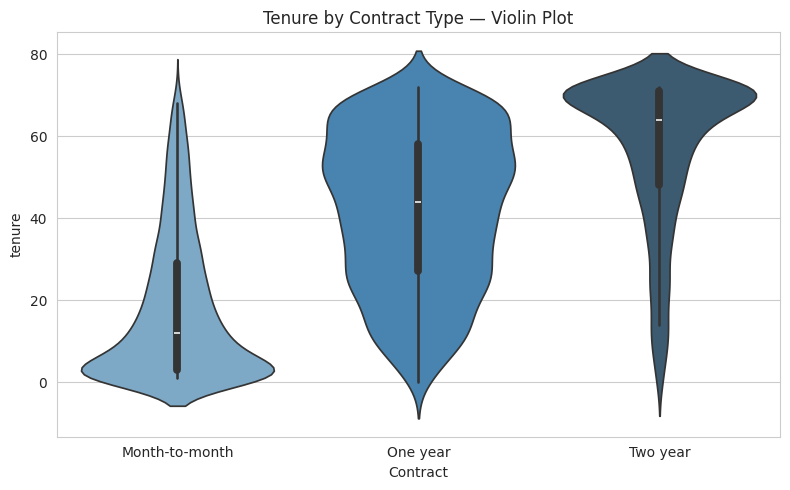

                mean  median
Contract                    
Month-to-month  18.0    12.0
One year        42.0    44.0
Two year        56.7    64.0


In [6]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Contract', y='tenure',
               order=['Month-to-month', 'One year', 'Two year'],
               hue='Contract', palette='Blues_d', legend=False)
plt.title('Tenure by Contract Type — Violin Plot')
plt.tight_layout()
plt.show()

print(df.groupby('Contract')['tenure'].agg(['mean', 'median']).round(1))


### Output
`Month-to-month`: mean tenure 18.0 months. `One year`: mean tenure 42.0 months.
`Two year`: mean tenure 56.7 months.

### Interpretation
Tenure rises sharply and consistently with longer contract commitment — this is expected
(customers must survive long enough to renew into a 1- or 2-year contract), but the
violin shapes also show `Month-to-month` has by far the widest spread, including many
very-low-tenure customers absent from the other two groups.

### Insight
This confirms `Contract` and `tenure` are related but not redundant — `Month-to-month`
specifically is where nearly all of the very-new, high-risk customers concentrate,
reinforcing why Contract type deserves the dedicated Categorical vs Categorical check
next.

### AI/ML Relevance
Because `Contract` and `tenure` are related but each adds distinct information, both are
worth keeping as separate features rather than treating one as redundant with the other.


---
# Part C — Categorical vs Categorical

Analogous to a classic "Product Category vs Sales" bivariate check — here, examining how
`Contract` and `PaymentMethod` relate to `Churn` using grouped bar charts and cross
tabulation.


---
## C1. `Contract` vs `Churn`

### Concept
A grouped bar chart and a cross-tabulation both show how two categorical variables
co-occur — here, specifically, whether churn RATE (not just raw count) differs across
contract types.

### Example
**AI/ML use case:** Directly testing Hypothesis 2 from Notebook 4 — this is one of the
most common and highest-value checks in any churn analysis.

### Implementation


Counts:
 Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Churn rate (%) within each contract type:
 

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


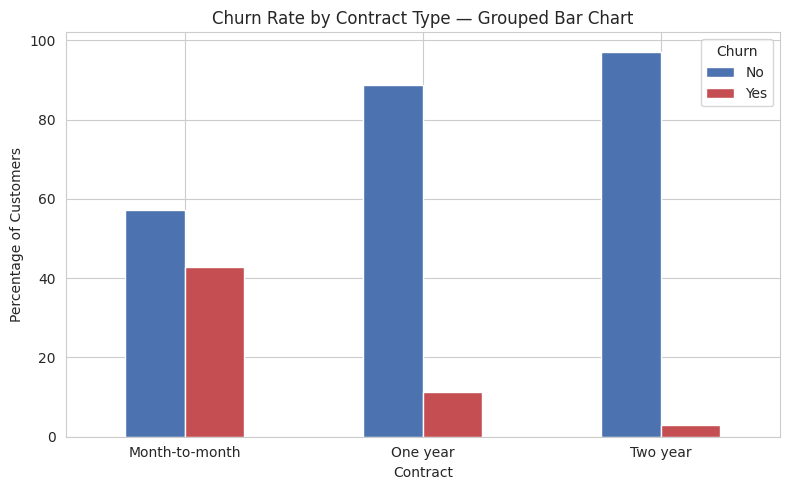

In [7]:
crosstab_counts = pd.crosstab(df['Contract'], df['Churn'])
crosstab_pct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

print("Counts:\n", crosstab_counts)
print("\nChurn rate (%) within each contract type:\n", crosstab_pct.round(1))

plt.figure(figsize=(8, 5))
crosstab_pct[['No', 'Yes']].loc[['Month-to-month', 'One year', 'Two year']].plot(
    kind='bar', stacked=False, color=['#4C72B0', '#C44E52'], ax=plt.gca())
plt.title('Churn Rate by Contract Type — Grouped Bar Chart')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Output
`Month-to-month` churn rate: 42.7%. `One year` churn rate: 11.3%. `Two year` churn rate:
2.8%.

### Interpretation
This is the single strongest relationship found in this entire notebook. Month-to-month
customers churn at roughly **15 times** the rate of two-year contract customers — a
massive, unambiguous difference, not a subtle trend.

### Insight
**Hypothesis 2 is not just confirmed, it's the dominant pattern in this dataset.**
Contract type alone nearly determines churn risk tier: month-to-month customers are the
company's overwhelming churn problem, while two-year customers are, by comparison,
almost entirely retained.

### AI/ML Relevance
`Contract` is very likely to emerge as the single most important feature in any model
trained on this data (testable formally with feature importance, Sprint 2, Notebook 12) —
and this specific finding, expressed in plain business terms, is exactly the kind of
insight Notebook 12 (Business Insights) is meant to capture and act on.


---
## C2. `PaymentMethod` vs `Churn`

### Concept
Directly testing Hypothesis 3 from Notebook 4 — do manual payment methods show higher
churn than automatic ones?

### Example
**Business example:** If manual payment methods correlate with higher churn, the company
could specifically encourage automatic payment enrollment as a low-cost retention lever.

### Implementation


Churn rate (%) within each payment method:
 Churn                        No   Yes
PaymentMethod                        
Electronic check           54.7  45.3
Mailed check               80.9  19.1
Bank transfer (automatic)  83.3  16.7
Credit card (automatic)    84.8  15.2


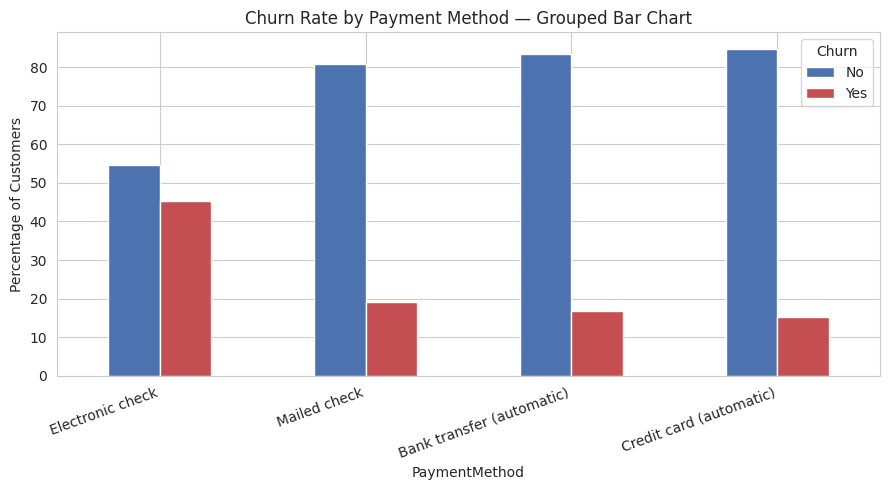

In [8]:
payment_crosstab_pct = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
payment_crosstab_pct = payment_crosstab_pct.sort_values('Yes', ascending=False)

print("Churn rate (%) within each payment method:\n", payment_crosstab_pct.round(1))

plt.figure(figsize=(9, 5))
payment_crosstab_pct[['No', 'Yes']].plot(kind='bar', color=['#4C72B0', '#C44E52'], ax=plt.gca())
plt.title('Churn Rate by Payment Method — Grouped Bar Chart')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


### Output
`Electronic check`: 45.3% churn. `Mailed check`: 19.1%. `Bank transfer (automatic)`:
16.7%. `Credit card (automatic)`: 15.2%.

### Interpretation
Electronic check customers churn at roughly 3x the rate of either automatic payment
method — a large, clear gap. The two automatic methods are close to each other and both
noticeably lower than either manual method.

### Insight
**Hypothesis 3 is confirmed, with Electronic check standing out as a specific,
disproportionate risk factor** — not "manual payments in general" so much as
"Electronic check" specifically being unusually high-risk, worth flagging as its own
distinct finding rather than lumping all manual methods together.

### AI/ML Relevance
This is a second strong categorical predictor (alongside `Contract`) worth explicitly
highlighting for feature importance testing later, and — like `Contract` — a direct,
actionable business lever (encouraging a switch away from Electronic check) rather than
just a modeling curiosity.


---
## C3. `InternetService` vs `Churn`

### Concept
A third categorical-vs-categorical check, chosen because `InternetService` (DSL / Fiber
optic / No) is a core product-type distinction, unlike `Contract` and `PaymentMethod`
which are billing/commitment-related.

### Example
**Business example:** Is one specific internet service type associated with unusually
high churn — perhaps reflecting a service-quality or pricing issue with that particular
offering?

### Implementation


Churn rate (%) within each internet service type:
 Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.6   7.4


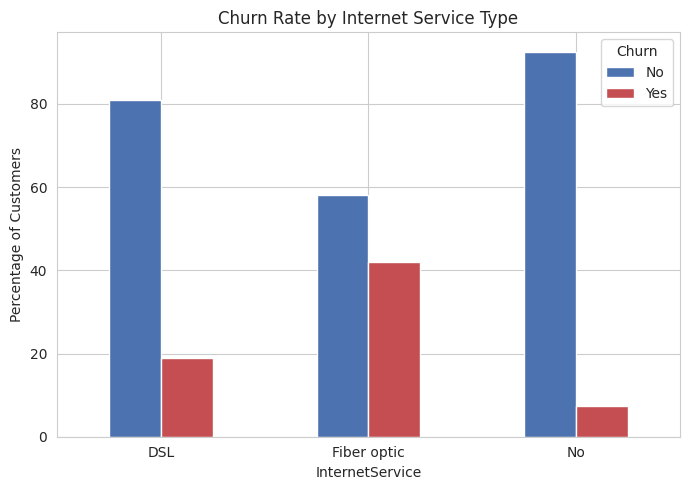

In [9]:
internet_crosstab_pct = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
print("Churn rate (%) within each internet service type:\n", internet_crosstab_pct.round(1))

plt.figure(figsize=(7, 5))
internet_crosstab_pct[['No', 'Yes']].plot(kind='bar', color=['#4C72B0', '#C44E52'], ax=plt.gca())
plt.title('Churn Rate by Internet Service Type')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Output
`Fiber optic`: 41.9% churn. `DSL`: 19.0% churn. `No internet service`: 7.4% churn.

### Interpretation
Fiber optic customers churn at more than double the rate of DSL customers, and nearly 6x
the rate of customers with no internet service at all — a genuinely surprising result,
since fiber is typically the "premium," presumably better-quality product.

### Insight
This is a finding that specifically warrants a business explanation rather than being
taken at face value — the most likely story is that fiber optic is also the most
*expensive* tier (worth quickly cross-checking against `MonthlyCharges`), meaning price
sensitivity, not service quality, may again be the underlying driver. This is exactly the
kind of pattern that needs `MonthlyCharges` (Part B) and `InternetService` considered
*together* in Notebook 6 (Multivariate Analysis), not in isolation.

### AI/ML Relevance
A single categorical variable rarely tells the whole story — this finding is a concrete
motivation for the multivariate view in the next notebook, where multiple features can be
examined together rather than one relationship at a time.


---
## Summary

| Relationship | Type | Key Finding |
|---|---|---|
| tenure vs MonthlyCharges | Num vs Num | Weak correlation (0.25) — largely independent |
| tenure vs TotalCharges | Num vs Num | Strong correlation (0.83) — expected, and a multicollinearity flag |
| MonthlyCharges vs Churn | Num vs Cat | Churners pay MORE on average ($74 vs $61) |
| tenure vs Churn | Num vs Cat | Churners have far LESS tenure (median 10 vs 38 months) — strongest numeric relationship found |
| tenure vs Contract | Num vs Cat | Tenure rises sharply with longer contract commitment |
| Contract vs Churn | Cat vs Cat | Month-to-month churns at ~15x the rate of Two-year — the single strongest finding in this notebook |
| PaymentMethod vs Churn | Cat vs Cat | Electronic check churns at ~3x the rate of automatic payment methods |
| InternetService vs Churn | Cat vs Cat | Fiber optic churns over 2x more than DSL — likely price-driven, to be confirmed |

**All three hypotheses from Notebook 4 are confirmed**, with `Contract` type emerging as
the dominant single relationship in the entire dataset.

**Open question carried forward to Notebook 6 (Multivariate Analysis):** Is
`InternetService`'s churn relationship actually being driven by `MonthlyCharges`
underneath it? Bivariate analysis alone can't separate these two overlapping
explanations — that requires looking at multiple variables together.

**Next notebook:** `06_Multivariate_Analysis.ipynb` — Correlation Matrix, Heatmap, Pair
Plot, and multi-feature relationships.
